In [1]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from datetime import datetime
import re

pd.set_option('display.max_columns', None)   # 显示所有列
pd.set_option('display.max_rows', 100)       # 最多显示100行（可自行调整）
pd.set_option('display.width', 200)          # 控制输出宽度，防止换行
pd.set_option('display.max_colwidth', 50)    # 控制每列的最大字符宽度（默认50，可改为None）

In [3]:
TRAIN_PATH = "C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_train_rent.csv"
TEST_PATH = "C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_test_rent.csv"
OUTPUT_TRAIN_PATH = "Rent_train_cleaned_with_text.csv"
OUTPUT_TEST_PATH = "Rent_test_cleaned_with_text.csv"


In [2]:
rent_train = pd.read_csv("C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_train_rent.csv")  # or train_price
rent_test = pd.read_csv("C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_test_rent.csv")    # or test_price

C:\Users\lenovo\AppData\Local\Temp\ipykernel_35304\974096613.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  rent_train = pd.read_csv("C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_train_rent.csv")  # or train_price


In [3]:
# 方法2：在Jupyter Notebook中
from DataClean_rent_v2 import *

In [4]:
train_file = "C:/Users/lenovo/Desktop/Data/ruc_Class25Q2_train_rent.csv"

# 返回元组 (DataFrame, encoders)
train_df, train_encoders = clean_rent_data_v2(
    train_file, 
    is_train=True, 
    save_encoders_flag=True,
    return_encoders=True  # 默认就是 True，可以省略
)

print(f"\n✓ 训练集形状: {train_df.shape}")
print(f"✓ 编码器数量: {len(train_encoders)}")

开始清洗训练集数据 (v2.0)

【第1步】加载数据...
原始数据形状: (98899, 46)

【第1.5步】统一缺失值表示...
  朝向: 替换了 9 个伪缺失值
  付款方式: 替换了 5 个伪缺失值
  开发商: 替换了 28 个伪缺失值
  停车费用: 替换了 1 个伪缺失值
总共替换了 43 个伪缺失值为NaN

【第2步】处理Price（目标变量）...
Price缺失数: 0
Price统计: 均值=582908.98, 中位数=394936.89

【第3步】清洗面积...
面积提取完成，缺失数: 0

【第4步】解析户型...

【第5步】解析楼层...

【第6步】解析交易时间...

【第7步】处理建筑年代...

【第8步】清洗数值型字段...

【第9步】处理二值特征...

【第10步】统计配套设施数量...

【第11步】创建衍生特征...
  创建特征: 均价

【第12步】填充分类变量的缺失值（层级众数）...
  装修: 73489 -> 0
  付款方式: 18428 -> 0
  环线位置: 69663 -> 0
  租期: 46933 -> 0
  车位: 74135 -> 0
  用水: 17740 -> 0
  用电: 17324 -> 0
  燃气: 4582 -> 0
  采暖: 64487 -> 0
  物业类别: 20124 -> 0
  朝向: 14 -> 0
  产权描述: 20124 -> 0
  供水: 21194 -> 0
  供暖: 61204 -> 0
  供电: 21200 -> 0
  建筑结构: 20741 -> 0
  配套设施: 30451 -> 0

【第13步】标准化分类变量...

【第14步】填充数值型变量的缺失值...

【第15步】板块和区县的目标编码...
  板块编码完成: 916 个板块
  区县编码完成: 104 个区县

【第16步】独热编码（单值分类变量）...
  单值分类独热编码完成，新增 113 列

【第17步】多标签独热编码...
  物业类别_标准: 26 个标签
  朝向_标准: 9 个标签
  产权描述_标准: 25 个标签
  供水_标准: 2 个标签
  供暖_标准: 3 个标签
  供电_标准: 2 个标签
  建筑结构_标准: 4 

In [8]:
train_df = train_df.drop(columns = ['朝向_标准_未知'])

In [10]:
print("\n" + "="*80)
print("示例 3: 测试集处理（只返回 DataFrame）")

test_file = "C:/Users/lenovo/Desktop/Data/ruc_Class25Q2_test_rent.csv"

# 加载训练集的编码器
loaded_encoders = load_encoders()

# 只返回 DataFrame
test_df = clean_rent_data_v2(
    test_file,
    is_train=False,
    encoders=loaded_encoders,
    return_encoders=False  # 只要 DataFrame
)

print(f"\n✓ 测试集形状: {test_df.shape}")


示例 3: 测试集处理（只返回 DataFrame）
✓ 已加载 13 个编码器
开始清洗测试集数据 (v2.0)

【第1步】加载数据...
原始数据形状: (9773, 46)

【第1.5步】统一缺失值表示...
  朝向: 替换了 2 个伪缺失值
  开发商: 替换了 6 个伪缺失值
总共替换了 8 个伪缺失值为NaN

【第2步】处理Price（目标变量）...

【第3步】清洗面积...
面积提取完成，缺失数: 0

【第4步】解析户型...

【第5步】解析楼层...

【第6步】解析交易时间...

【第7步】处理建筑年代...

【第8步】清洗数值型字段...

【第9步】处理二值特征...

【第10步】统计配套设施数量...

【第11步】创建衍生特征...

【第12步】填充分类变量的缺失值（层级众数）...
  装修: 2682 -> 0
  付款方式: 2387 -> 0
  环线位置: 6962 -> 0
  租期: 5175 -> 0
  车位: 7611 -> 0
  用水: 2273 -> 0
  用电: 2227 -> 0
  燃气: 591 -> 0
  采暖: 6560 -> 0
  物业类别: 2625 -> 0
  朝向: 2 -> 0
  产权描述: 2625 -> 0
  供水: 2762 -> 0
  供暖: 6195 -> 0
  供电: 2760 -> 0
  建筑结构: 2699 -> 0
  配套设施: 3694 -> 0

【第13步】标准化分类变量...

【第14步】填充数值型变量的缺失值...

【第15步】板块和区县的目标编码...
  ✓ 使用训练集的板块编码
  ✓ 使用训练集的区县编码

【第16步】独热编码（单值分类变量）...
  单值分类独热编码完成，新增 113 列

【第17步】多标签独热编码...
  物业类别_标准: 26 个标签
  朝向_标准: 9 个标签
  产权描述_标准: 25 个标签
  供水_标准: 2 个标签
  供暖_标准: 3 个标签
  供电_标准: 2 个标签
  建筑结构_标准: 4 个标签
  配套设施_标准: 11 个标签
  多标签独热编码完成，新增 82 列

【第18步】城市独热编码...
  城市编码完成，生成 12 列

【第19步】删

In [11]:
test_df = test_df.drop(columns = ['朝向_标准_未知'])

In [12]:
# ============================================================================
# 示例 4: 对齐测试集和训练集的列
# ============================================================================
print("\n" + "="*80)
print("示例 4: 对齐测试集和训练集的列")

test_df_aligned = align_columns(test_df, train_df)

print(f"\n✓ 对齐后测试集形状: {test_df_aligned.shape}")
print(f"✓ 训练集列数: {train_df.shape[1]}")
print(f"✓ 列数是否一致: {test_df_aligned.shape[1] == train_df.shape[1]}")


示例 4: 对齐测试集和训练集的列

对齐训练集和测试集的列

训练集列数: 238
测试集列数: 238
测试集缺少的列: 0
测试集多余的列: 0

✓ 对齐完成！测试集最终列数: 239

✓ 对齐后测试集形状: (9773, 239)
✓ 训练集列数: 239
✓ 列数是否一致: True


### 聚类小区

Fitting HDBSCAN on training coords...
clusters found: 3
example cluster sizes (top 10): [5000, 5000, 5000]
Train cluster id value counts (top 10):
cluster_id
2    5000
1    5000
0    5000
Name: count, dtype: int64
Test cluster id value counts (top 10):
cluster_id
-1    3000
Name: count, dtype: int64
p90s median: 15308.57875555823 p90s 75pct: 15708.058270807407


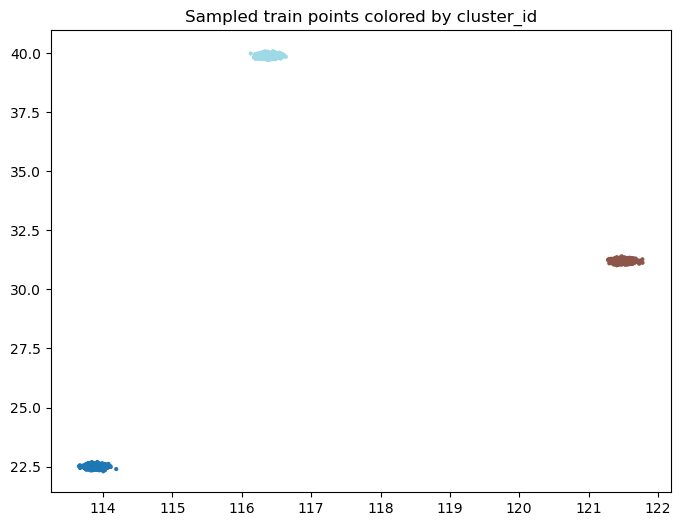

encoder saved to hdbscan_geo_encoder.joblib


In [14]:
"""
改进版 HDBSCANGeoEncoder（替换 / 更新你当前的类）

主要修改与增强：
- fit 时强制开启 prediction_data=True（以便 hdbscan.approximate_predict 可用）
- transform 中对 approximate_predict 使用 try/except，并在不可用或返回低置信度时稳健回退到 BallTree 的 kNN 加权投票或 radius 投票
- 提供 compute_cluster_radii 帮助选择 eps_m（基于簇内距离的 p50/p75/p90 分位数）
- 增强兼容性与健壮性（检测 prediction_data_、处理 hdbscan 版本差异）
- 提供 save/load（joblib）以及 explore_min_cluster_size 辅助函数

依赖: pip install hdbscan scikit-learn numpy pandas joblib
"""
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree
import hdbscan
from collections import Counter
import joblib
import math
import warnings

EARTH_RADIUS = 6371000.0  # m

def deg2rad_degorder(coords_deg):
    """
    输入: Nx2 array [lon, lat] degrees
    输出: Nx2 array [lat_rad, lon_rad]
    """
    arr = np.asarray(coords_deg, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("coords must be shape (n,2) [lon, lat]")
    rad = np.radians(arr)
    return np.vstack([rad[:,1], rad[:,0]]).T  # [lat_rad, lon_rad]

def haversine_angle_rad(a, b):
    """
    计算球面中心角（弧度）
    a: [lat_rad, lon_rad] 或形状 (...,2)
    b: (...,2) 或单点
    返回: array radians
    """
    a = np.asarray(a)
    b = np.asarray(b)
    # support broadcasting: if b is (n,2) and a is (2,) or (m,2)
    lat1 = a[..., 0]
    lon1 = a[..., 1]
    lat2 = b[..., 0]
    lon2 = b[..., 1]
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    sa = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    sa = np.minimum(1.0, np.maximum(0.0, sa))
    return 2.0 * np.arcsin(np.sqrt(sa))

def rad_to_m(rad):
    return rad * EARTH_RADIUS

class HDBSCANGeoEncoder:
    """
    HDBSCANGeoEncoder: 在训练集上 fit 一次 HDBSCAN，然后对新点做可复用的编码/分配。

    参数:
      min_cluster_size, min_samples, eps_m (meters fallback radius),
      assign_strategy: 'approximate' | 'nearest' | 'keep_noise'
      hdbscan_params: dict 额外传给 hdbscan.HDBSCAN
      hdbscan_prob_threshold: 若 approximate_predict 返回 strength < 阈值则视为低置信度，触发 fallback
      knn_k: fallback 时使用的 kNN 个数（加权投票）
    """
    def __init__(self, min_cluster_size=50, min_samples=None, eps_m=500,
                 assign_strategy='nearest', hdbscan_params=None, hdbscan_prob_threshold=0.05,
                 knn_k=3):
        assert assign_strategy in ('approximate', 'nearest', 'keep_noise')
        self.min_cluster_size = min_cluster_size
        self.min_samples = min_samples
        self.eps_m = eps_m
        self.assign_strategy = assign_strategy
        self.hdbscan_params = hdbscan_params or {}
        self.hdbscan_prob_threshold = hdbscan_prob_threshold
        self.knn_k = knn_k

        self.clusterer_ = None
        self.train_rad_ = None  # Nx2 [lat_rad, lon_rad]
        self.train_deg_ = None  # Nx2 [lon, lat]
        self.train_labels_ = None
        self.balltree_ = None
        self.cluster_centers_rad_ = {}  # label -> [lat_rad, lon_rad]
        self.cluster_sizes_ = {}
        self.cluster_persistence_ = {}
        self.fitted = False

    def fit(self, coords_deg):
        """
        在训练集上 fit HDBSCAN.
        coords_deg: array-like Nx2 [lon, lat] degrees OR DataFrame with ['lon','lat']
        注意: 强制 prediction_data=True 以支持 approximate_predict
        """
        if isinstance(coords_deg, pd.DataFrame):
            coords_deg = coords_deg[['lon','lat']].values
        coords_deg = np.asarray(coords_deg, dtype=float)
        self.train_deg_ = coords_deg.copy()
        self.train_rad_ = deg2rad_degorder(coords_deg)  # [lat_rad, lon_rad]

        params = dict(min_cluster_size=self.min_cluster_size,
                      metric='haversine',
                      prediction_data=True,   # 关键：生成 prediction_data_ 以便 approximate_predict 使用
                      core_dist_n_jobs=4)
        if self.min_samples is not None:
            params['min_samples'] = self.min_samples
        params.update(self.hdbscan_params)

        # fit
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=".*force_all_finite.*", category=FutureWarning)
            self.clusterer_ = hdbscan.HDBSCAN(**params)
            self.clusterer_.fit(self.train_rad_)

        labels = self.clusterer_.labels_
        self.train_labels_ = labels
        # BallTree for fallback assignment; metric='haversine' expects radian input [lat, lon]
        self.balltree_ = BallTree(self.train_rad_, metric='haversine')

        # compute centers and sizes
        uniq = set(labels)
        for lab in uniq:
            if lab == -1:
                continue
            mask = (labels == lab)
            pts = self.train_rad_[mask]
            if pts.shape[0] == 0:
                continue
            lat_mean = float(np.mean(pts[:,0]))
            lon_mean = float(np.mean(pts[:,1]))
            self.cluster_centers_rad_[lab] = np.array([lat_mean, lon_mean])
            self.cluster_sizes_[lab] = int(mask.sum())

        # persistence if available
        try:
            pers = getattr(self.clusterer_, 'cluster_persistence_', None)
            if pers is not None:
                # try mapping cluster indices to labels best-effort
                if isinstance(pers, dict):
                    self.cluster_persistence_ = pers.copy()
                else:
                    labs_sorted = sorted([l for l in set(labels) if l != -1])
                    for i, lab in enumerate(labs_sorted):
                        if i < len(pers):
                            self.cluster_persistence_[lab] = float(pers[i])
        except Exception:
            # 不影响主流程
            pass

        self.fitted = True
        return self

    def _knn_weighted_vote(self, coords_rad, k=3, max_dist_m=None):
        """
        对一组点使用 kNN 加权投票分配标签（忽略训练中 label==-1）
        coords_rad: Nx2 [lat_rad, lon_rad]
        返回: labels array
        """
        n = coords_rad.shape[0]
        labels_out = np.full(n, -1, dtype=int)
        dists_rad, idxs = self.balltree_.query(coords_rad, k=k)
        dists_m = dists_rad * EARTH_RADIUS  # shape (n,k)
        for i in range(n):
            labs = self.train_labels_[idxs[i]]  # k labels
            # filter out -1 neighbors
            mask = (labs != -1)
            if mask.sum() == 0:
                labels_out[i] = -1
                continue
            labs = labs[mask]
            dms = dists_m[i][mask]
            if (max_dist_m is not None) and (dms.min() > max_dist_m):
                labels_out[i] = -1
                continue
            # weights: inverse distance
            w = 1.0 / (dms + 1e-6)
            vote_scores = {}
            for lab, wi in zip(labs, w):
                vote_scores[int(lab)] = vote_scores.get(int(lab), 0.0) + wi
            chosen = max(vote_scores.items(), key=lambda x: x[1])[0]
            labels_out[i] = int(chosen)
        return labels_out

    def _radius_vote(self, coords_rad, radius_m):
        """
        半径内多数投票（radius-based). radius_m in meters
        """
        radius_rad = radius_m / EARTH_RADIUS
        idxs_list = self.balltree_.query_radius(coords_rad, r=radius_rad, return_distance=False)
        n = coords_rad.shape[0]
        labels_out = np.full(n, -1, dtype=int)
        for i, neigh in enumerate(idxs_list):
            if len(neigh) == 0:
                labels_out[i] = -1
            else:
                labs = self.train_labels_[neigh]
                c = Counter(labs[labs != -1])
                if len(c) == 0:
                    labels_out[i] = -1
                else:
                    labels_out[i] = c.most_common(1)[0][0]
        return labels_out

    def transform(self, coords_deg, return_more=False):
        """
        Assign cluster ids to coords_deg (lon, lat deg)
        return_more: if True, returns (labels, cluster_size, dist_to_center_m, membership_strength)
        """
        if not self.fitted:
            raise RuntimeError("Call fit() before transform()")
        if isinstance(coords_deg, pd.DataFrame):
            coords_deg = coords_deg[['lon','lat']].values
        coords_deg = np.asarray(coords_deg, dtype=float)
        coords_rad = deg2rad_degorder(coords_deg)  # [lat_rad, lon_rad]
        n = coords_rad.shape[0]
        labels_out = np.full(n, -1, dtype=int)
        cluster_size_arr = np.zeros(n, dtype=int)
        dist_to_center_m = np.full(n, np.nan, dtype=float)
        strength_arr = np.full(n, np.nan, dtype=float)

        # 尝试 approximate_predict（如果可用且 prediction data 存在）
        use_approx = hasattr(hdbscan, 'approximate_predict') and getattr(self.clusterer_, 'prediction_data_', None) is not None
        if use_approx:
            try:
                labs, strengths = hdbscan.approximate_predict(self.clusterer_, coords_rad)
                labels_out = np.array(labs, dtype=int)
                strength_arr = np.array(strengths, dtype=float)
            except Exception:
                use_approx = False

        # 处理 approximate_predict 的低置信度或 label == -1 情况，根据策略回退
        if use_approx:
            low_mask = (strength_arr < self.hdbscan_prob_threshold)
            # 若 assign_strategy 是 nearest，则对低置信度/噪声尝试 knn 加权投票或 radius 投票
            if self.assign_strategy == 'nearest':
                # 先对 low confidence / -1 使用 knn weighted vote (k=self.knn_k) 并限制 max_dist = eps_m
                idxs_low = np.where((labels_out == -1) | low_mask)[0]
                if idxs_low.size > 0:
                    coords_low = coords_rad[idxs_low]
                    assigned = self._knn_weighted_vote(coords_low, k=self.knn_k, max_dist_m=self.eps_m)
                    for i, lab in zip(idxs_low, assigned):
                        labels_out[i] = int(lab)
                        if lab != -1:
                            strength_arr[i] = 0.0  # 标注为低置信度分配
            elif self.assign_strategy == 'keep_noise':
                # 保持 approximate_predict 的结果（包括 -1）
                pass
            elif self.assign_strategy == 'approximate':
                # 接受 approximate_predict 即使 strength 低
                pass
        else:
            # approximate_predict 不可用或失败 -> 直接使用 knn weighted vote 或 radius vote
            if self.assign_strategy == 'nearest':
                labels_out = self._knn_weighted_vote(coords_rad, k=self.knn_k, max_dist_m=self.eps_m)
            elif self.assign_strategy == 'keep_noise':
                labels_out = np.full(n, -1, dtype=int)
            elif self.assign_strategy == 'approximate':
                # 没有 approximate_predict 就相当于 keep_noise
                labels_out = np.full(n, -1, dtype=int)

        # 计算 cluster_size 和 dist_to_center
        for i, lab in enumerate(labels_out):
            if lab == -1:
                continue
            cluster_size_arr[i] = self.cluster_sizes_.get(lab, 0)
            center = self.cluster_centers_rad_.get(lab, None)
            if center is not None:
                ang = haversine_angle_rad(center, coords_rad[i])
                dist_to_center_m[i] = rad_to_m(ang)

        if return_more:
            return labels_out, cluster_size_arr, dist_to_center_m, strength_arr
        return labels_out

    def fit_transform(self, coords_deg, return_more=False):
        self.fit(coords_deg)
        return self.transform(coords_deg, return_more=return_more)

    def save(self, path):
        joblib.dump(self, path)

    @staticmethod
    def load(path):
        return joblib.load(path)


# ----------------------------
# Utility: compute cluster radii & explore helper
# ----------------------------
def compute_cluster_radii(enc):
    """
    输入 enc (fit 完的 HDBSCANGeoEncoder)，输出每个簇到簇心距离统计（米）
    返回: dict label -> {'n','p50','p75','p90','p95','max'}
    """
    if not enc.fitted:
        raise RuntimeError("encoder not fitted")
    stats = {}
    labels = enc.train_labels_
    centers = enc.cluster_centers_rad_
    coords = enc.train_rad_
    unique_labels = [l for l in np.unique(labels) if l != -1]
    for lab in unique_labels:
        mask = (labels == lab)
        pts = coords[mask]
        if pts.shape[0] == 0:
            continue
        center = centers.get(lab, None)
        if center is None:
            continue
        angs = haversine_angle_rad(center, pts)  # radians
        dists_m = angs * EARTH_RADIUS
        stats[lab] = {
            'n': int(mask.sum()),
            'p50': float(np.percentile(dists_m, 50)),
            'p75': float(np.percentile(dists_m, 75)),
            'p90': float(np.percentile(dists_m, 90)),
            'p95': float(np.percentile(dists_m, 95)),
            'max': float(np.max(dists_m))
        }
    return stats

def explore_min_cluster_size(coords_deg, min_sizes=(10,20,30,50,80,120), min_samples=None):
    """
    Sweep 不同 min_cluster_size 的影响（返回 DataFrame）
    """
    res = []
    for mcs in min_sizes:
        enc = HDBSCANGeoEncoder(min_cluster_size=mcs, min_samples=min_samples or max(1, mcs//3))
        enc.fit(coords_deg)
        labs = enc.train_labels_
        ncl = len(set(labs)) - (1 if -1 in labs else 0)
        noise_frac = float(np.mean(labs == -1))
        sizes = list(enc.cluster_sizes_.values())
        median_size = float(np.median(sizes)) if len(sizes)>0 else 0.0
        res.append({'min_cluster_size': mcs, 'n_clusters': ncl, 'noise_frac': noise_frac, 'median_cluster_size': median_size})
    return pd.DataFrame(res)


# ----------------------------
# Example usage（脚本直接运行时）
# ----------------------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # demo 数据（替换为你的 df_train/df_test）
    n = 20000
    rng = np.random.RandomState(0)
    centers = [(116.4,39.9),(121.5,31.2),(113.9,22.5),(108.9,34.3)]
    pts = []
    for cx, cy in centers:
        pts.append(np.vstack([rng.normal(cx, 0.08, n//len(centers)), rng.normal(cy, 0.06, n//len(centers))]).T)
    coords = np.vstack(pts)
    df_train = pd.DataFrame(coords[:15000], columns=['lon','lat'])
    df_test = pd.DataFrame(coords[15000:18000], columns=['lon','lat'])

    enc = HDBSCANGeoEncoder(min_cluster_size=50, min_samples=10, eps_m=500, assign_strategy='nearest', knn_k=3)
    print("Fitting HDBSCAN on training coords...")
    enc.fit(df_train[['lon','lat']].values)
    print("clusters found:", len(enc.cluster_centers_rad_))
    print("example cluster sizes (top 10):", sorted(enc.cluster_sizes_.values(), reverse=True)[:10])

    labs_tr, size_tr, dist_tr, strength_tr = enc.transform(df_train[['lon','lat']].values, return_more=True)
    labs_te, size_te, dist_te, strength_te = enc.transform(df_test[['lon','lat']].values, return_more=True)

    df_train['cluster_id'] = labs_tr
    df_train['cluster_size'] = size_tr
    df_train['dist_to_center_m'] = dist_tr
    df_train['cluster_strength'] = strength_tr

    df_test['cluster_id'] = labs_te
    df_test['cluster_size'] = size_te
    df_test['dist_to_center_m'] = dist_te
    df_test['cluster_strength'] = strength_te

    print("Train cluster id value counts (top 10):")
    print(df_train['cluster_id'].value_counts().head(10))
    print("Test cluster id value counts (top 10):")
    print(df_test['cluster_id'].value_counts().head(10))

    # compute cluster radii stats and suggest eps_m
    stats = compute_cluster_radii(enc)
    p90s = np.array([v['p90'] for v in stats.values()])
    if len(p90s) > 0:
        print("p90s median:", np.median(p90s), "p90s 75pct:", np.percentile(p90s,75))
    else:
        print("No clusters to compute radii.")

    # simple sampled plot
    sample_tr = df_train.sample(min(3000, len(df_train)), random_state=0)
    plt.figure(figsize=(8,6))
    plt.scatter(sample_tr['lon'], sample_tr['lat'], c=sample_tr['cluster_id'], cmap='tab20', s=4)
    plt.title('Sampled train points colored by cluster_id')
    plt.show()

    enc.save('hdbscan_geo_encoder.joblib')
    print("encoder saved to hdbscan_geo_encoder.joblib")

In [17]:
cluster_train = train_df[['lon','lat']]
cluster_test = test_df[['lon','lat']]

Fitting HDBSCAN on training coords...
clusters found: 2383
example cluster sizes (top 10): [830, 649, 556, 415, 407, 402, 374, 358, 356, 306]
Train cluster id value counts (top 10):
cluster_id
-1       4831
 704      833
 17       649
 1086     556
 2032     415
 933      407
 789      402
 957      374
 512      358
 167      356
Name: count, dtype: int64
Test cluster id value counts (top 10):
cluster_id
-1       691
 933      73
 789      54
 1281     54
 957      46
 1183     45
 900      40
 896      38
 433      38
 44       38
Name: count, dtype: int64


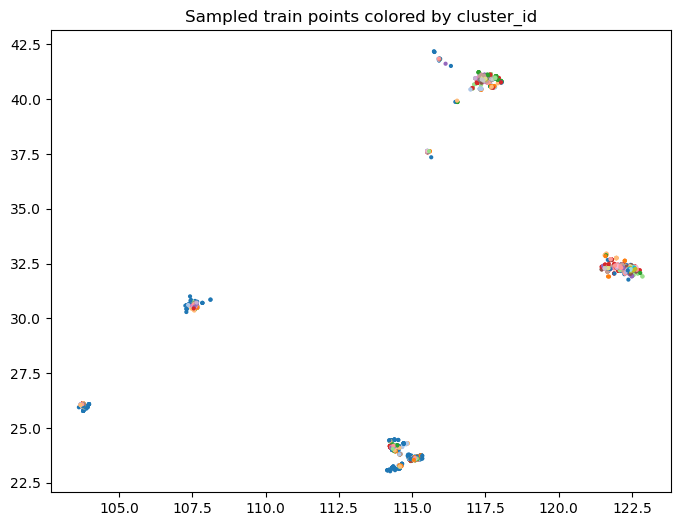

encoder saved to hdbscan_geo_encoder.joblib


In [28]:
# 假设 HDBSCANGeoEncoder 类已正确定义并导入为 enc
enc = HDBSCANGeoEncoder(min_cluster_size=5, min_samples=10, eps_m=1000, assign_strategy='nearest')
print("Fitting HDBSCAN on training coords...")
enc.fit(cluster_train[['lon','lat']].values)

print("clusters found:", len(enc.cluster_centers_rad_))
print("example cluster sizes (top 10):", sorted(enc.cluster_sizes_.values(), reverse=True)[:10])

# transform train & test (注意这里 test 用 cluster_test)
labs_tr, size_tr, dist_tr, strength_tr = enc.transform(cluster_train[['lon','lat']].values, return_more=True)
labs_te, size_te, dist_te, strength_te = enc.transform(cluster_test[['lon','lat']].values, return_more=True)

cluster_train['cluster_id'] = labs_tr
cluster_train['cluster_size'] = size_tr
cluster_train['dist_to_center_m'] = dist_tr
cluster_train['cluster_strength'] = strength_tr

cluster_test['cluster_id'] = labs_te
cluster_test['cluster_size'] = size_te
cluster_test['dist_to_center_m'] = dist_te
cluster_test['cluster_strength'] = strength_te

print("Train cluster id value counts (top 10):")
print(cluster_train['cluster_id'].value_counts().head(10))
print("Test cluster id value counts (top 10):")
print(cluster_test['cluster_id'].value_counts().head(10))

# simple plot (sampled)
sample_tr = cluster_train.sample(min(3000, len(cluster_train)), random_state=0)
plt.figure(figsize=(8,6))
plt.scatter(sample_tr['lon'], sample_tr['lat'], c=sample_tr['cluster_id'], cmap='tab20', s=4)
plt.title('Sampled train points colored by cluster_id')
plt.show()

# save encoder for later use
enc.save('hdbscan_geo_encoder.joblib')
print("encoder saved to hdbscan_geo_encoder.joblib")

In [29]:
# 简单实现
import pandas as pd
train_df['Price/m2'] = train_df['Price'] / train_df['面积_数值']
cluster_train['price'] = train_df['Price/m2']
global_mean = cluster_train['price'].mean()


# 训练集：每行填充自己簇的均值
cluster_train['cluster_price_mean'] = cluster_train.groupby('cluster_id')['price'].transform('mean')

# 计算训练集上的簇均值字典（用于映射 test）
cluster_means = cluster_train.groupby('cluster_id')['price'].mean().to_dict()

# 测试集：用训练集统计的均值映射，未见簇或 NaN 填充全局均值
cluster_test['cluster_price_mean'] = cluster_test['cluster_id'].map(cluster_means)

In [30]:
train_df['cluster_id'] = cluster_train['cluster_id']
train_df['cluster_mean_price'] = cluster_train['cluster_price_mean']
test_df['cluster_id'] = cluster_test['cluster_id']
test_df['cluster_mean_price'] = cluster_test['cluster_price_mean']

In [32]:
mask = train_df['cluster_id'] == -1
train_df.loc[mask, 'cluster_mean_price'] = train_df.loc[mask, '板块_价格编码']

In [33]:
mask = test_df['cluster_id'] == -1
test_df.loc[mask, 'cluster_mean_price'] = test_df.loc[mask, '板块_价格编码']

In [34]:
train_df.to_csv("C:/Users\lenovo\Desktop\Data/train_rent_clean_v6.csv", index=False)
test_df.to_csv("C:/Users\lenovo\Desktop\Data/test_rent_clean_v6.csv", index=False)